In [1]:
import os
import re
import glob

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(0)
print('GPU:', tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import zipfile
import gdown

FILE_ID = '1fKswXSsLj1KbBO8Sot856ZrJhaTtJGMn'
ZIP_PATH = '/content/utkface.zip'
EXTRACT_DIR = '/content/utkface'

gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print(os.listdir(EXTRACT_DIR))

Downloading...
From (original): https://drive.google.com/uc?id=1fKswXSsLj1KbBO8Sot856ZrJhaTtJGMn
From (redirected): https://drive.google.com/uc?id=1fKswXSsLj1KbBO8Sot856ZrJhaTtJGMn&confirm=t&uuid=c52b8774-3842-4a90-a300-3fa43d2c214a
To: /content/utkface.zip
100%|██████████| 347M/347M [00:06<00:00, 53.9MB/s]


['crop_part1', 'utkface_aligned_cropped', 'UTKFace']


In [3]:
all_jpgs = glob.glob(f'{EXTRACT_DIR}/**/*.jpg', recursive=True)
image_paths = [
    p for p in all_jpgs
    if re.match(r'^\d+_\d+_\d+_', os.path.basename(p))
    and 'crop_part1' not in p
    and 'aligned' not in p.lower()
]

ages = np.array([int(os.path.basename(p).split('_')[0]) for p in image_paths], dtype=np.float32)

print('Number of photos:', len(image_paths))
print('Age range:', ages.min(), 'Until', ages.max())

Number of photos: 23705
Age range: 1.0 Until 116.0


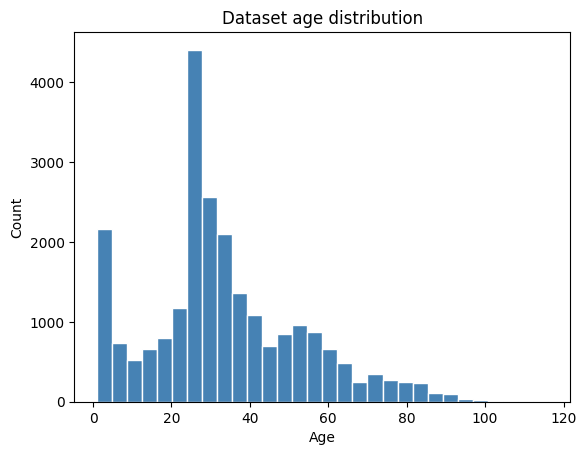

In [4]:
plt.hist(ages, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Dataset age distribution')
plt.show()

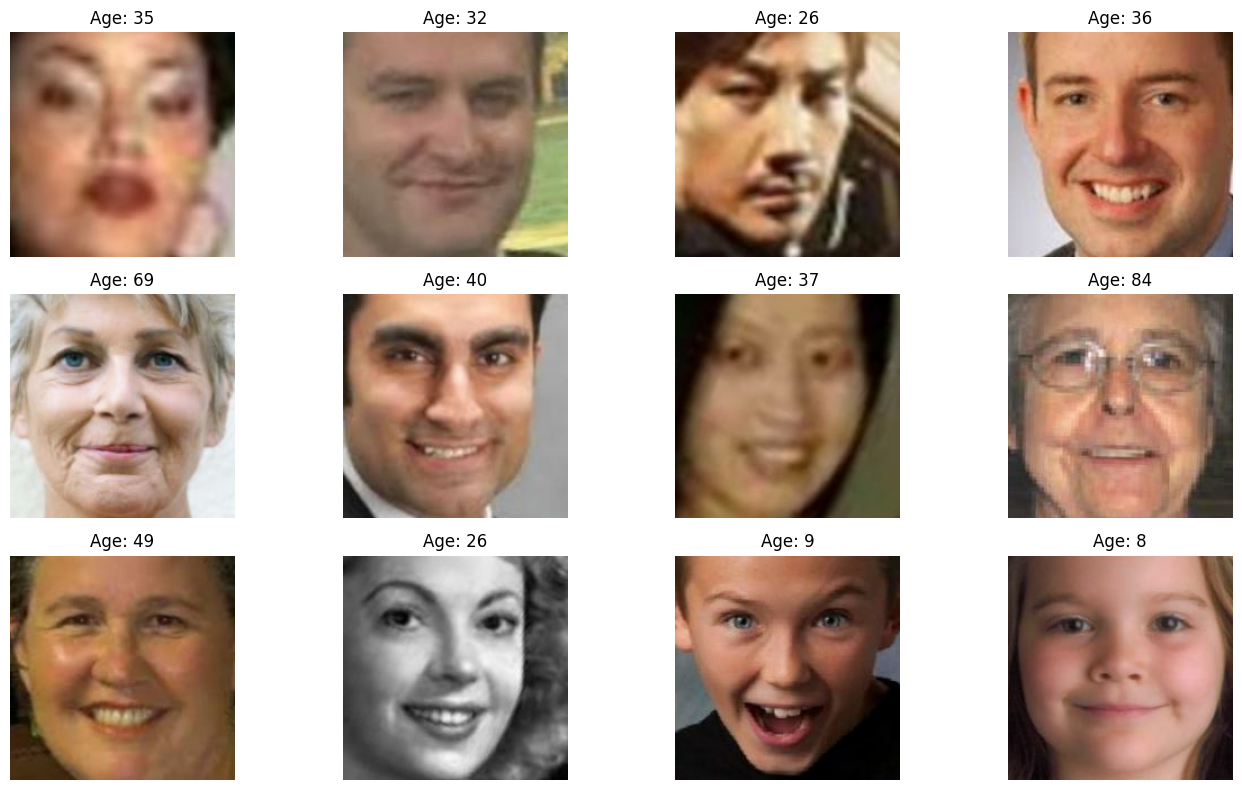

In [5]:
sample_idx = np.random.choice(len(image_paths), 12, replace=False)
plt.figure(figsize=(14, 8))
for i, idx in enumerate(sample_idx):
    img = tf.io.decode_jpeg(tf.io.read_file(image_paths[idx]))
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f'Age: {int(ages[idx])}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
paths_train, paths_temp, ages_train, ages_temp = train_test_split(
    image_paths, ages, test_size=0.2, random_state=0
)
paths_valid, paths_test, ages_valid, ages_test = train_test_split(
    paths_temp, ages_temp, test_size=0.5, random_state=0
)

print('train:', len(paths_train), '| valid:', len(paths_valid), '| test:', len(paths_test))

train: 18964 | valid: 2370 | test: 2371


In [7]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 64
MAX_AGE = 100.0

def load_image(path, age):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, age / MAX_AGE

def make_dataset(paths, ages, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, ages))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=0)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(paths_train, ages_train, shuffle=True)
valid_ds = make_dataset(paths_valid, ages_valid)
test_ds = make_dataset(paths_test, ages_test)

In [8]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = augment(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history1 = model.fit(train_ds, validation_data=valid_ds, epochs=15, callbacks=[early_stop])

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - loss: 0.0203 - mae: 0.1064 - val_loss: 0.0144 - val_mae: 0.0915
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - loss: 0.0156 - mae: 0.0920 - val_loss: 0.0137 - val_mae: 0.0878
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - loss: 0.0146 - mae: 0.0884 - val_loss: 0.0127 - val_mae: 0.0828
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 23s 77ms/step - loss: 0.0140 - mae: 0.0867 - val_loss: 0.0130 - val_mae: 0.0858
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - loss: 0.0137 - mae: 0.0855 - val_loss: 0.0130 - val_mae: 0.0842
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 39s 68ms/step - loss: 0.0135 - mae: 0.0848 - val_loss: 0.0126 - val_mae: 0.0832
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - loss: 0.0132 - mae: 0.0839 - val_loss: 0.0123 - val_mae: 0.0816
Epoch 8/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 0.0133 - mae: 0.0841 - val_loss: 0.0132 - val_mae: 0.0876
Epoch 9/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='mse',
    metrics=['mae']
)

history2 = model.fit(train_ds, validation_data=valid_ds, epochs=20, callbacks=[early_stop])

Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 56s 153ms/step - loss: 0.0075 - mae: 0.0632 - val_loss: 0.0076 - val_mae: 0.0638
Epoch 2/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 146ms/step - loss: 0.0073 - mae: 0.0622 - val_loss: 0.0074 - val_mae: 0.0623
Epoch 3/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 147ms/step - loss: 0.0068 - mae: 0.0604 - val_loss: 0.0080 - val_mae: 0.0658
Epoch 4/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 148ms/step - loss: 0.0066 - mae: 0.0594 - val_loss: 0.0074 - val_mae: 0.0635
Epoch 5/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 147ms/step - loss: 0.0064 - mae: 0.0587 - val_loss: 0.0075 - val_mae: 0.0636
Epoch 6/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - loss: 0.0062 - mae: 0.0576 - val_loss: 0.0067 - val_mae: 0.0592
Epoch 7/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 147ms/step - loss: 0.0062 - mae: 0.0577 - val_loss: 0.0066 - val_mae: 0.0578
Epoch 8/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 148ms/step - loss: 0.0058 - mae: 0.0561 - val_loss: 0.0070 - val_mae: 0.0613
Epoch 9/20
297/297 ━━━━━━━━━━━━━

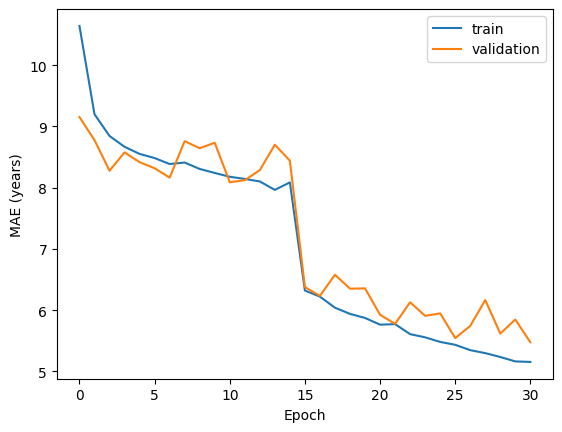

In [12]:
mae = np.array(history1.history['mae'] + history2.history['mae']) * MAX_AGE
val_mae = np.array(history1.history['val_mae'] + history2.history['val_mae']) * MAX_AGE

plt.plot(mae, label='train')
plt.plot(val_mae, label='validation')
plt.xlabel('Epoch')
plt.ylabel('MAE (years)')
plt.legend()
plt.show()

In [13]:
y_pred = model.predict(test_ds, verbose=0).ravel() * MAX_AGE
y_true = ages_test

mae_test = mean_absolute_error(y_true, y_pred)
print(f'MAE ON test: {mae_test:.2f} YEAR')

MAE ON test: 5.74 YEAR


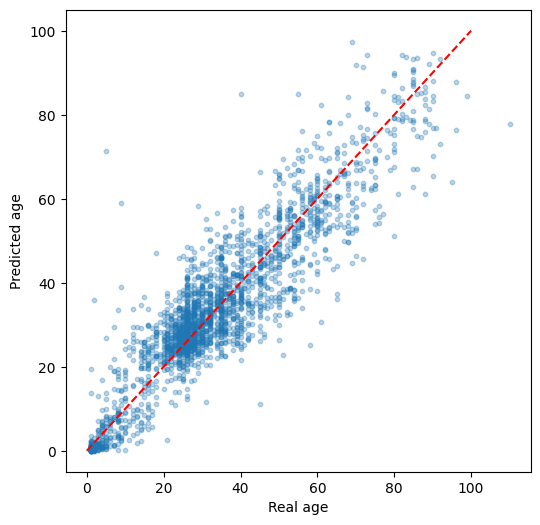

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Real age')
plt.ylabel('Predicted age')
plt.show()

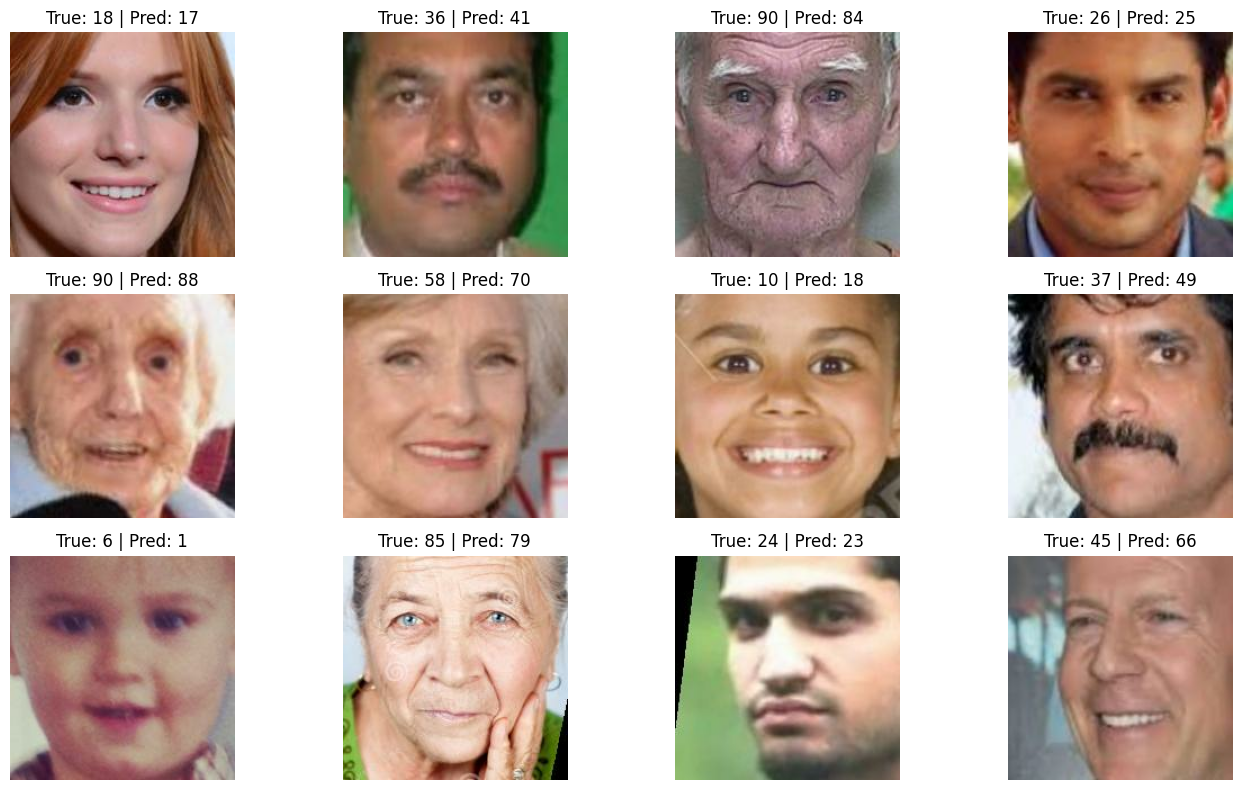

In [15]:
sample_idx = np.random.choice(len(paths_test), 12, replace=False)
plt.figure(figsize=(14, 8))
for i, idx in enumerate(sample_idx):
    img = tf.io.decode_jpeg(tf.io.read_file(paths_test[idx]))
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f'True: {int(y_true[idx])} | Pred: {y_pred[idx]:.0f}')
    plt.axis('off')
plt.tight_layout()
plt.show()